KNeighborsClassifier()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        47
           3       0.98      1.00      0.99        54
           4       0.98      1.00      0.99        60
           5       0.98      0.98      0.98        66
           6       1.00      1.00      1.00        53
           7       1.00      1.00      1.00        55
           8       1.00      1.00      1.00        43
           9       0.98      0.95      0.97        59

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540



'\nclf=KNeighborsClassifier(n_neighbors=K)\nscoring={\'accuracy\':make_scorer(accuracy_score),\n         \'precision\':make_scorer(precision_score),\n         \'recall\':make_scorer(recall_score),\n         \'f1\':make_scorer(f1_score)}\ncv_results=cross_validate(clf, data.data, data.target, cv=10, scoring=scoring)\nfor metric in scoring.keys():\n    mean_score=cv_results[f\'test_{metric}\'].mean()\n    std_score=cv_results[f\'test_{metric}\'].std()\n    print(f"{metric}: mean={mean_score:.3f}, std={std_score:.3f}")\n'

accuracy: mean=0.988, std=0.007
precision: mean=0.989, std=0.007
recall: mean=0.988, std=0.007
f1-score: mean=0.988, std=0.007


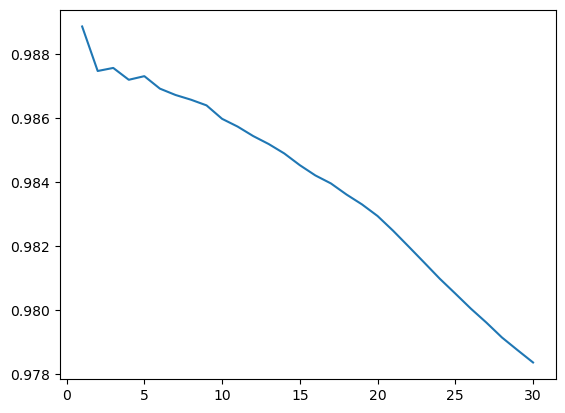

the best value for k is 1 which gives an accuracy of 98.88516449410304%.


In [6]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#____________________________ part a ______________________________#
# loading data
from sklearn.datasets import load_digits

data=load_digits()
#data.data.shape
#data.target.shape

# split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(data.data, data.target, test_size=0.3, random_state=42)

#____________________________ part b ______________________________#
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

#____________________________ part c ______________________________#
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

K=5
clf=KNeighborsClassifier(n_neighbors=K)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
report=classification_report(y_test,y_pred)
print(report)

#____________________________ part d ______________________________#
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np 

"""
clf=KNeighborsClassifier(n_neighbors=K)
scoring={'accuracy':make_scorer(accuracy_score),
         'precision':make_scorer(precision_score),
         'recall':make_scorer(recall_score),
         'f1':make_scorer(f1_score)}
cv_results=cross_validate(clf, data.data, data.target, cv=10, scoring=scoring)
for metric in scoring.keys():
    mean_score=cv_results[f'test_{metric}'].mean()
    std_score=cv_results[f'test_{metric}'].std()
    print(f"{metric}: mean={mean_score:.3f}, std={std_score:.3f}")
"""
def knn_cv(dataset, n_folds, n_neighbours):
    clf=KNeighborsClassifier(n_neighbors=n_neighbours)
    cv=KFold(n_splits=n_folds, random_state=15, shuffle=True)
    accuracy_scores=[]
    precision_scores=[]
    recall_scores=[]
    f1_scores=[]
    X=dataset.data
    y=dataset.target
    for train_index, test_index in cv.split(X):
        X_train, y_train=X[train_index], y[train_index]
        X_test, y_test=X[test_index], y[test_index]
        #print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)
        clf.fit(X_train,y_train)
        y_pred=clf.predict(X_test)
        accuracy_scores.append(accuracy_score(y_test,y_pred))
        precision_scores.append(precision_score(y_test,y_pred,average='weighted'))
        recall_scores.append(recall_score(y_test,y_pred,average='weighted'))
        f1_scores.append(f1_score(y_test,y_pred,average='weighted'))
    print(f"accuracy: mean={np.mean(accuracy_scores):.3f}, std={np.std(accuracy_scores):.3f}")
    print(f"precision: mean={np.mean(precision_scores):.3f}, std={np.std(precision_scores):.3f}")
    print(f"recall: mean={np.mean(recall_scores):.3f}, std={np.std(recall_scores):.3f}")
    print(f"f1-score: mean={np.mean(f1_scores):.3f}, std={np.std(f1_scores):.3f}")

knn_cv(data, 10, K)

#____________________________ part e ______________________________#
import matplotlib.pyplot as plt

def optimize_k(dataset, n_folds, k_start, k_stop):
    cv=KFold(n_splits=n_folds, random_state=15, shuffle=True)
    accuracy_scores=[]
    hist=[]
    X=dataset.data
    y=dataset.target
    for k in range(k_start,k_stop+1):
        clf=KNeighborsClassifier(n_neighbors=k)
        for train_index, test_index in cv.split(X):
            X_train, y_train=X[train_index], y[train_index]
            X_test, y_test=X[test_index], y[test_index]
            clf.fit(X_train,y_train)
            y_pred=clf.predict(X_test)
            accuracy_scores.append(accuracy_score(y_test,y_pred))
        hist.append(np.mean(accuracy_scores))
    plt.plot(list(range(k_start,k_stop+1)),hist)
    plt.show()
    print(f"the best value for k is {hist.index(max(hist))+k_start} which gives an accuracy of {max(hist)*100}%.")

optimize_k(data,10,1,30)
